In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import cmocean as cmo
import matplotlib
import momlevel as ml

## Preprocessing

In [ ]:
import psutil
from dask.distributed import Client, LocalCluster

# Detect system resources
n_physical_cores = psutil.cpu_count(logical=False)
n_logical_cores = psutil.cpu_count(logical=True)
total_mem = psutil.virtual_memory().total  # in bytes

# Decide how much memory to give to Dask (80% of total)
mem_per_worker = int((total_mem * 0.8) / n_physical_cores)

print(f"Physical cores: {n_physical_cores}")
print(f"Logical cores: {n_logical_cores}")
print(f"Total memory: {round(total_mem/1024**3, 2)} GB")
print(f"Memory per worker: {round(mem_per_worker/1024**3, 2)} GB")

# Set up the cluster
cluster = LocalCluster(
    n_workers=n_physical_cores,
    threads_per_worker=1,  # keep workers isolated
    memory_limit=mem_per_worker,
)

client = Client(cluster)
print(client)

In [ ]:
ds_BGOSE = xr.open_dataset("iceshelves_bgose_v2.nc").rename({"lat": "YC", "lon": "XC"})

ds_SOhi = xr.open_dataset("data/SOhi.static.nc")

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1)
(ds_SOhi.ID >= 1).plot(ax=axs[0], cmap="binary", add_colorbar=False)
(ds_BGOSE.ID >= 1).plot(ax=axs[1], cmap="binary", add_colorbar=False)

for i in range(2):
    axs[i].set_ylim([-85, -63])
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")

axs[0].set_title("SOhi ice shelf mask")
axs[1].set_title("BGOSE ice shelf mask")
plt.tight_layout()
plt.savefig("figures/mask_comparison_named.png", format="png", dpi=150)

In [3]:
ds1 = xr.open_dataset("SHIfwFlx_bgoseI012_2013to_monthly.nc")
test = ds1.SHIfwFlx.mean(dim="time").compute()
test = test != 0
idx_mask = ds_BGOSE.ID >= 1
idx_notmasked = ~idx_mask

type: name 'ds_BGOSE' is not defined

In [ ]:
c1 = 60**2 * 365 * 24 * 1e-3  # convert kg m-2 s-1 to m yr-1
melt_nonmasked = c1 * test * idx_notmasked * ds1.SHIfwFlx[-36:, :, :].mean(dim="time")
melt_nonmasked = xr.where(melt_nonmasked, melt_nonmasked, np.nan)

melt_mask_2 = np.ones(shape=np.shape(melt_nonmasked)) * np.nan

for i in range(1080):
    for j in range(307):
        # check that there is both melt and that it is not already included in the first SOhi mask
        if ~np.isnan(ds_BGOSE.ID[j, i]):
            melt_mask_2[j, i] = ds_BGOSE.ID[j, i].data

        elif ~np.isnan(melt_nonmasked[j, i]):
            # create radius that we will check to see how far we are from the any ice shelf
            melt_subgroup = ds_BGOSE.ID[j - 4 : j + 4, i - 4 : i + 4]
            nearby_ids, c = np.unique(melt_subgroup, return_counts=True)

            if len(nearby_ids) == 1:  # this will be just nan
                melt_mask_2[j, i] = 0  # generic flag
            elif (
                len(nearby_ids) == 2
            ):  # there is only 1 ice shelf in the area, name is same as ice shelf
                melt_mask_2[j, i] = nearby_ids[~np.isnan(nearby_ids)]
            elif (
                len(nearby_ids) > 2
            ):  # more than 1 ice shelf nearby -- add to that which has more?
                max_c = np.max(c[~np.isnan(nearby_ids)])
                melt_mask_2[j, i] = -0  # just a stopgap measure
                # if len(c==max_c) == 1:
                #    melt_mask_2[j,i] = nearby_ids[c==max_c]
                # else:
                #    melt_subgroup = ds_BGOSE.ID[j-2:j+2, i-2:i+2]
                #    nearby_ids, c = np.unique(melt_subgroup, return_counts=True)
                #    melt_mask_2[j,i] = nearby_ids[c==max_c]

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6, 9))

(ds_SOhi.ID >= 1).plot(ax=axs[0], cmap="binary", add_colorbar=False)
(ds_BGOSE.ID >= 1).plot(ax=axs[1], cmap="binary", add_colorbar=False)
axs[2].pcolormesh(ds_BGOSE.XC.data, ds_BGOSE.YC.data, melt_mask_2 > 0, cmap="binary")
test.plot(ax=axs[3], cmap="binary", add_colorbar=False)

for i in range(4):
    axs[i].set_ylim([-85, -63])
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")

axs[0].set_title("SOhi ice shelf mask")
axs[1].set_title("BGOSE ice shelf mask, version 1")
axs[2].set_title("BGOSE ice shelf mask w/ nearest neighbor extension")
axs[3].set_title("BGOSE shelf melt area")

plt.tight_layout()
plt.savefig("figures/mask_comparison_named_2.png", format="png", dpi=150)

In [ ]:
ds_out_mask = xr.Dataset(
    data_vars=dict(
        shelf_mask=(["YC", "XC"], melt_mask_2),
    ),
    coords=dict(
        XC=("XC", ds_BGOSE.XC.data),
        YC=("YC", ds_BGOSE.YC.data),
    ),
)

ds_out_mask.to_netcdf("iceshelves_bgose_extended.nc")

## Meltrates by group and area

In [2]:
Names = [
    "Generic",
    "Larsen G",
    "Larsen F",
    "Larsen E",
    "Larsen D",
    "Larsen C",
    "Larsen B",
    "Wordie",
    "Wilkins",
    "Bach",
    "George VI",
    "Stange",
    "Ronne",
    "Ferrigno",
    "Venable",
    "Abbot",
    "Cosgrove",
    "Pine Island",
    "Thwaites",
    "Crosson",
    "Dotson",
    "Getz",
    "Land",
    "Nickerson",
    "Sulzberger",
    "Swinburne",
    "Withrow",
    "Ross West",
    "Ross East",
    "Drygalski",
    "Nansen",
    "Aviator",
    "Mariner",
    "Lillie",
    "Rennick",
    "Cook",
    "Ninnis",
    "Mertz",
    "Dibble",
    "Holmes",
    "Moscow University",
    "Totten",
    "Vincennes",
    "Conger_Glenzer",
    "Tracy_Tremenchus",
    "Shackleton",
    "West",
    "Publications",
    "Amery",
    "Wilma_Robert_Downer",
    "Edward VIII",
    "Rayner_Thyer",
    "Shirase",
    "Prince Harald",
    "Baudouin",
    "Borchgrevink",
    "Lazarev",
    "Nivl",
    "Vigrid",
    "Fimbul",
    "Jelbart",
    "Atka",
    "Ekstrom",
    "Quar",
    "Riiser-Larsen",
    "Brunt_Stancomb",
    "Filchner",
]

In [22]:
#ds1 = xr.open_dataset("SHIfwFlx_bgoseI013_2013to_monthly.nc", use_cftime=True)
ds_BGOSE = xr.open_dataset("iceshelves_bgose6_extended.nc")

In [43]:
Gt_per_yr = -1 * 60**2 * 24 * 365 * 1e-12
m_per_year = -1 * 60**2 * 365 * 24 * 1e-3 

In [5]:
Names[1:12]  # Antarctic Peninsula
Names[13:27]  # W Antarctica (no Ronne or Ross)
Names[27:29]  # Ross Sea
Names[29:-1]  # E Antarctica (no Filchner or Ross)
Names[12], Names[-1]  # Ronne-Filchner

('Ronne', 'Filchner')

In [23]:
idx_AP = ds_BGOSE.shelf_mask.isin(np.arange(1, 12))
idx_WA = ds_BGOSE.shelf_mask.isin(np.arange(13, 27))
idx_RS = ds_BGOSE.shelf_mask.isin(np.arange(27, 29))
idx_EA = ds_BGOSE.shelf_mask.isin(np.arange(29, 66))
idx_RF = ds_BGOSE.shelf_mask.isin([12, 66])
idx_other = ds_BGOSE.shelf_mask == 0

#(idx_AP + 2 * idx_WA + 3 * idx_RS + 4 * idx_EA + 5 * idx_RF).plot(
#    cmap=plt.get_cmap("viridis", 6)
#)

In [12]:
# for generic ice shelves to be attributed into different regions - ignore RS and RF for now

region_AP = (ds1.YC > -75) & (ds1.YC < -63) & (ds1.XC < 360 - 55) & (ds1.XC > 360 - 80)
region_WA = (ds1.YC > -78) & (ds1.YC < -70) & (ds1.XC < 360 - 80) & (ds1.XC > 360 - 160)
region_EA = (ds1.YC > -78) & (ds1.YC < -64) & ((ds1.XC < 178) | (ds1.XC > 360 - 50))

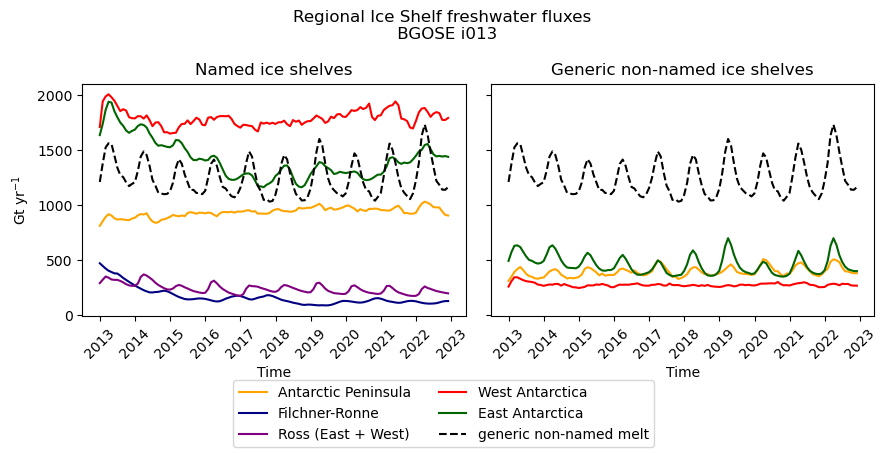

In [13]:
fig, axs = plt.subplots(ncols=2, nrows=1, sharey=True, figsize=(9, 4.5))

(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_AP).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="orange", label="Antarctic Peninsula"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_RF).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="navy", label="Filchner-Ronne"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_RS).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="purple", label="Ross (East + West)"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_WA).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="red", label="West Antarctica"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_EA).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="darkgreen", label="East Antarctica"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="black", linestyle="dashed", label="generic non-named melt"
)

(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="black", linestyle="dashed", label="generic non-named melt"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other * region_AP).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="orange", label="Antarctic Peninsula"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other * region_WA).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="red", label="West Antarctica"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other * region_EA).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="darkgreen", label="East Antarctica"
)

#axs[0].legend()
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2)
axs[0].set_ylabel("Gt yr$^{-1}$")

plt.suptitle("Regional Ice Shelf freshwater fluxes \n BGOSE i013")
axs[0].set_title("Named ice shelves")
axs[1].set_title("Generic non-named ice shelves")

for i in range(2):
    axs[i].tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
#plt.show()

plt.savefig("figures/BGOSEi013_regional_flux_incl_generic.png", format="png", dpi=150)

In [ ]:
c1 = 60**2 * 365 * 24 * 1e-3  # convert kg m-2 s-1 to m yr-1

# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

avg_melt = c1 * ds1.SHIfwFlx[-36:, :, :].mean(dim="time")
avg_melt = xr.where(avg_melt, avg_melt, np.nan)

ax = plt.axes(projection=ccrs.SouthPolarStereo())

avg_melt.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-5,
    vmax=5,
    extend="neither",
    cmap="RdBu",
    cbar_kwargs={"label": "m yr$^{-1}$"},
)
ax.set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
ax.gridlines(alpha=0.3, linestyle="dashed")
ax.set_boundary(circle, transform=ax.transAxes)
ax.coastlines(linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")

plt.title("BGOSE i013 average melt, 2020-2023")
plt.savefig("figures/BGOSEi013_avg_flux.png", format="png", dpi=150)

In [ ]:
avg_melt = c1 * ds1.SHIfwFlx[24 + 6 :: 12, :, :].mean(dim="time")
avg_melt = xr.where(avg_melt, avg_melt, np.nan)

In [ ]:
ax = plt.axes(projection=ccrs.SouthPolarStereo())

avg_melt.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-5,
    vmax=5,
    extend="neither",
    cmap="RdBu",
    cbar_kwargs={"label": "m yr$^{-1}$"},
)
ax.set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
ax.gridlines(alpha=0.3, linestyle="dashed")
ax.set_boundary(circle, transform=ax.transAxes)
ax.coastlines(linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")

plt.title("BGOSE i012 August average melt, 2015-2023")
plt.savefig("figures/BGOSE_aug_flux.png", format="png", dpi=150)

## Seasonality of ice shelf meltwater fluxes

In [7]:
SHI_detrended = ml.trend.linear_detrend(ds1.SHIfwFlx[13:,:,:])
seasonal_model, resid = ml.trend.seasonal_model(SHI_detrended, return_model=True)
seasonal_model2 = seasonal_model.groupby(seasonal_model.time.dt.month).mean()

In [8]:
seasonal_amp = seasonal_model2.max(dim='month') - seasonal_model2.min(dim='month')

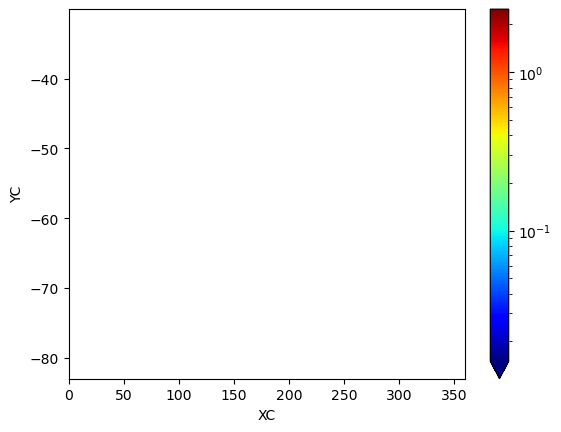

In [9]:
seasonal_amp2 = xr.where(seasonal_amp == 0, np.nan, seasonal_amp)
(m_per_year * seasonal_amp2).plot(x='XC', norm=matplotlib.colors.LogNorm(), cmap='jet', vmax=2.5e0, vmin=1.5e-2)

var_exp = (SHI_detrended - seasonal_model).var(dim='time')/SHI_detrended.var(dim='time')

In [17]:
seasonal_model_masked = xr.where((1 - var_exp) >= .25, seasonal_model2 + ds1.SHIfwFlx[13:,:,:].mean(dim='time'), 0)
seasonal_amp_masked = seasonal_model_masked.max(dim='month') - seasonal_model_masked.min(dim='month')

minmonth_masked = seasonal_model_masked.argmin(dim='month', skipna=True) + 1
maxmonth_masked = seasonal_model_masked.argmax(dim='month', skipna=True) + 1

minmonth_masked2 = xr.where(minmonth_masked == maxmonth_masked, np.nan, minmonth_masked)
maxmonth_masked2 = xr.where(minmonth_masked == maxmonth_masked, np.nan, maxmonth_masked)

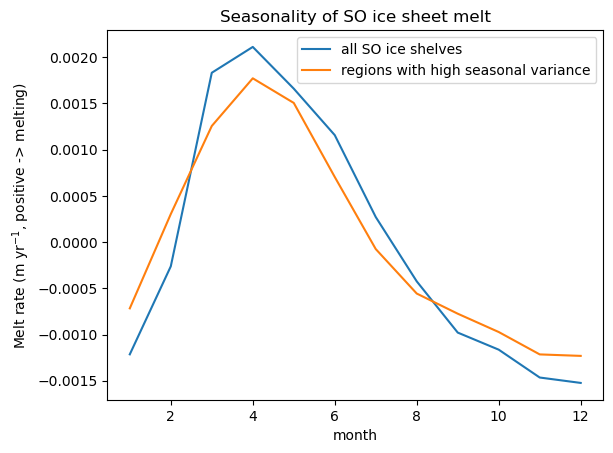

In [19]:
seasonal_SO = ds1.SHIfwFlx[13:,:,:].groupby(ds1.time[13:].dt.month).mean().weighted(weights=ds1.rA).mean(dim=['XC', 'YC'])
seasonal_SO_hivar = seasonal_model_masked.weighted(weights=ds1.rA).mean(dim=['XC', 'YC'])


(m_per_year*(seasonal_SO - seasonal_SO.mean())).plot(label='all SO ice shelves')
(m_per_year*(seasonal_SO_hivar - seasonal_SO_hivar.mean())).plot(label='regions with high seasonal variance')
plt.legend()

plt.title('Seasonality of SO ice sheet melt')
plt.ylabel('Melt rate (m yr$^{-1}$, positive -> melting)')
plt.savefig('figures/BGOSE6_i000_seasonality.png', format='png')

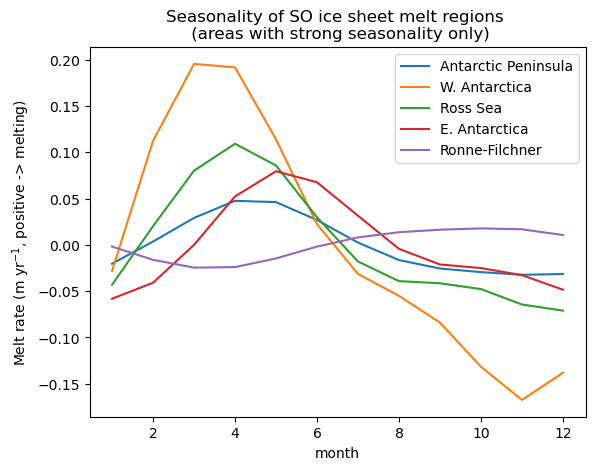

In [25]:
seasonal_AP_hivar = seasonal_model_masked.weighted(weights=ds1.rA*idx_AP).mean(dim=['XC', 'YC'])
seasonal_WA_hivar = seasonal_model_masked.weighted(weights=ds1.rA*idx_WA).mean(dim=['XC', 'YC'])
seasonal_RS_hivar = seasonal_model_masked.weighted(weights=ds1.rA*idx_RS).mean(dim=['XC', 'YC'])
seasonal_EA_hivar = seasonal_model_masked.weighted(weights=ds1.rA*idx_EA).mean(dim=['XC', 'YC'])
seasonal_RF_hivar = seasonal_model_masked.weighted(weights=ds1.rA*idx_RF).mean(dim=['XC', 'YC'])


#(m_per_year*(seasonal_SO_hivar - seasonal_SO_hivar.mean())).plot(color='black', label='pan-SO')
(m_per_year*(seasonal_AP_hivar - seasonal_AP_hivar.mean())).plot(label = "Antarctic Peninsula")
(m_per_year*(seasonal_WA_hivar - seasonal_WA_hivar.mean())).plot(label = "W. Antarctica")
(m_per_year*(seasonal_RS_hivar - seasonal_RS_hivar.mean())).plot(label = "Ross Sea")
(m_per_year*(seasonal_EA_hivar - seasonal_EA_hivar.mean())).plot(label = "E. Antarctica")
(m_per_year*(seasonal_RF_hivar - seasonal_RF_hivar.mean())).plot(label = "Ronne-Filchner")
plt.legend()

plt.title('Seasonality of SO ice sheet melt regions \n (areas with strong seasonality only)')
plt.ylabel('Melt rate (m yr$^{-1}$, positive -> melting)')
plt.savefig('figures/BGOSE6_i000_seasonality_regional.png', format='png')

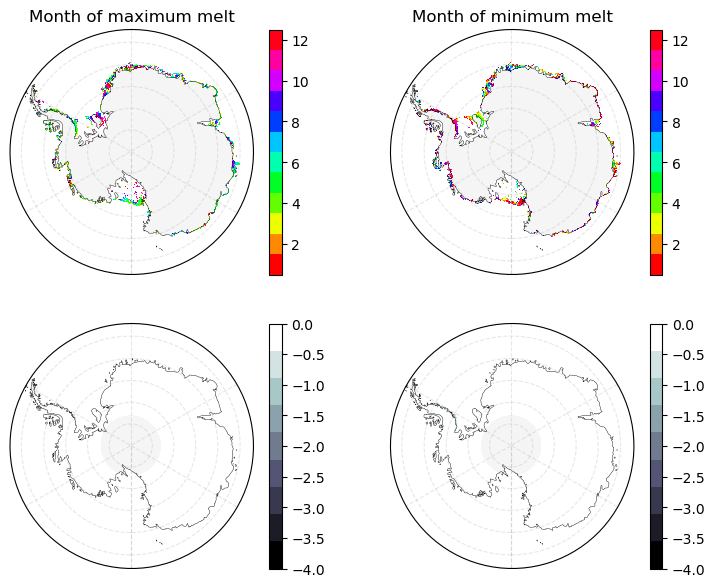

In [26]:
#(m_per_year * seasonal_amp_masked).plot(x='XC', norm=matplotlib.colors.LogNorm(), cmap='jet', vmax=2.5e0, vmin=1.5e-2) 
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

fig, axs = plt.subplots(nrows=2, ncols=2,
                       subplot_kw={'projection': ccrs.SouthPolarStereo()},
                       figsize=(9,7))

axs = axs.flatten()

minmonth_masked2.plot(ax=axs[0], x='XC', transform=ccrs.PlateCarree(),
                      cmap=plt.get_cmap('hsv', 12), vmin=0.5, vmax=12.5)
axs[0].set_title('Month of maximum melt')
maxmonth_masked2.plot(ax=axs[1], x='XC', transform=ccrs.PlateCarree(),
                      cmap=plt.get_cmap('hsv', 12), vmin=0.5, vmax=12.5)
axs[1].set_title('Month of minimum melt')


(m_per_year*seasonal_model_masked.min(dim='month')).plot(ax=axs[2], x='XC', transform=ccrs.PlateCarree(),
                                                        vmin=-4, vmax=0, cmap=plt.get_cmap('bone',9), 
                                                         extend='neither',
                                                        )
(m_per_year*seasonal_model_masked.max(dim='month')).plot(ax=axs[3], x='XC', transform=ccrs.PlateCarree(),
                                                         vmin=-4, vmax=0, cmap=plt.get_cmap('bone',9), 
                                                         extend='neither',
                                                        )

for i in range(4):
    axs[i].set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.3, linestyle="dashed")
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines(linewidth=0.3)
    axs[i].add_feature(cfeature.LAND, facecolor="whitesmoke")
    
plt.savefig('figures/seasonality_masked_phases_BGOSE6.png', format='png', dpi=150)

In [27]:
# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

fig, axs = plt.subplots(ncols=2, nrows=1, 
                        dpi=150,
                        figsize=(8,4),
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})

axs=axs.flatten()

(m_per_year * seasonal_amp2).plot(x='XC',
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    norm=matplotlib.colors.LogNorm(),
    robust=True,
    cmap='jet',
    #vmin=-4,
    #vmax=2,
    #extend="neither",
    #cmap=cmo.cm.phase,
    cbar_kwargs={"label": "log$_{10}$(m yr$^{-1}$)"},
)
axs[0].set_title('Annual cycle amplitude')

(100 * (1 - var_exp)).plot(x='XC',
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    #norm=matplotlib.colors.LogNorm(),
    robust=True,
    cmap=plt.get_cmap('viridis', 10),
    vmin=10,
    vmax=60,
    #extend="neither",
    cbar_kwargs={"label": "Percentage"},
)
axs[1].set_title('Fraction of variance explained')

for i in range(2):
    axs[i].set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.3, linestyle="dashed")
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines(linewidth=0.3)
    axs[i].add_feature(cfeature.LAND, facecolor="whitesmoke")

plt.tight_layout()
plt.savefig('figures/analysis_harmonic_seasonality_BGOSE6.png', format='png', dpi=150)

type: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x161acbba0> (for post_execute):


AttributeError: 'Colorbar' object has no attribute '_boundaries'

AttributeError: 'Colorbar' object has no attribute '_boundaries'

<Figure size 1200x600 with 3 Axes>

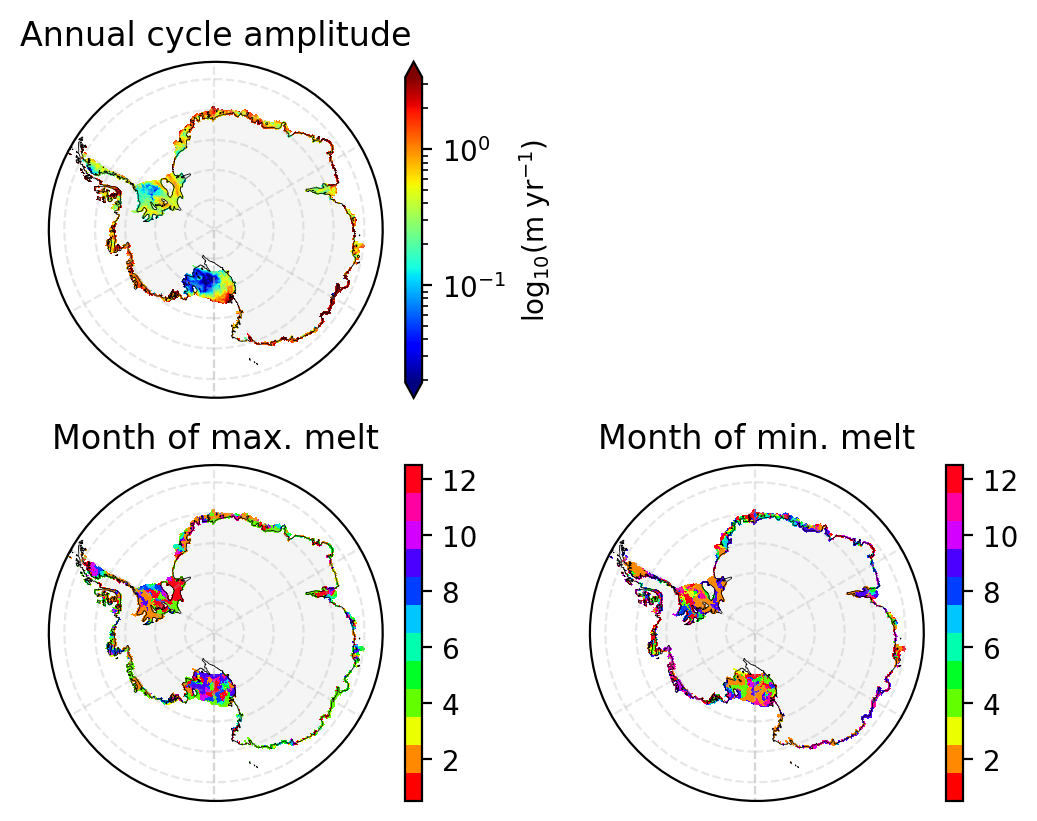

In [119]:
(1 + mask * fw_flux_clim.argmax(dim='month', skipna=True)).plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    vmin=0.5,
    vmax=12.5,
    #extend="neither",
    cmap=plt.get_cmap('hsv', 12),
    cbar_kwargs={"label": ""},
)
axs[2].set_title('Month of max. melt')

(1 + mask * fw_flux_clim.argmin(dim='month', skipna=True)).plot(
    ax=axs[3],
    transform=ccrs.PlateCarree(),
    vmin=0.5,
    vmax=12.5,
    #extend="neither",
    cmap=plt.get_cmap('hsv', 12),
    cbar_kwargs={"label": ""},
)
axs[3].set_title('Month of min. melt')

for i in range(4):
    axs[i].set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.3, linestyle="dashed")
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines(linewidth=0.3)
    axs[i].add_feature(cfeature.LAND, facecolor="whitesmoke")
    
axs[1].remove()

#plt.savefig('figures/annual_cycle.png', format='png', dpi=200)

In [70]:
Names[17:19]

['Pine Island', 'Thwaites']

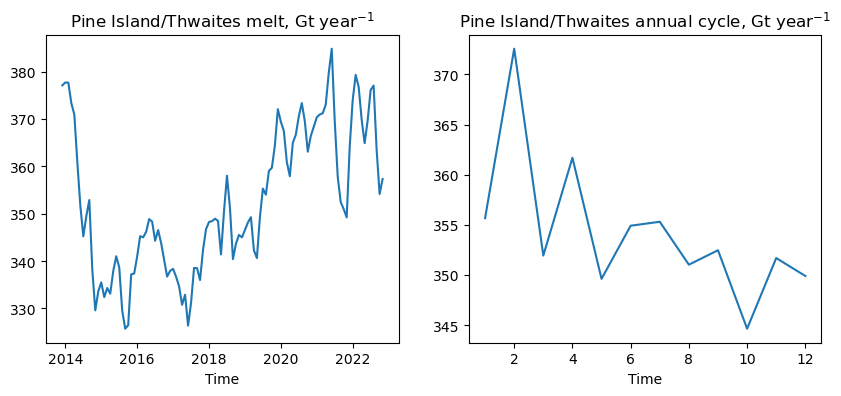

In [148]:
PI_T_melt = (c_Gt * ds1.rA * ds1.SHIfwFlx[12:,:,:]).sel(YC=slice(-75.7,-73.95)).sel(XC=slice(251,261)).sum(dim=['YC', 'XC'])

fig, axs = plt.subplots(figsize = (10,4), nrows=1, ncols=2)
PI_T_melt.plot(ax=axs[0])
axs[0].set_xticks(PI_T_melt.time[1::24])
axs[0].set_xticklabels(PI_T_melt.time[1::24].dt.year.data)
axs[0].set_title('Pine Island/Thwaites melt, Gt year$^{-1}$')

PI_T_melt.groupby(PI_T_melt.time.dt.month).mean().plot()
axs[1].set_title('Pine Island/Thwaites annual cycle, Gt year$^{-1}$')

plt.savefig('figures/BGOSEi013_PI_T_ts.png', format='png', dpi=100)

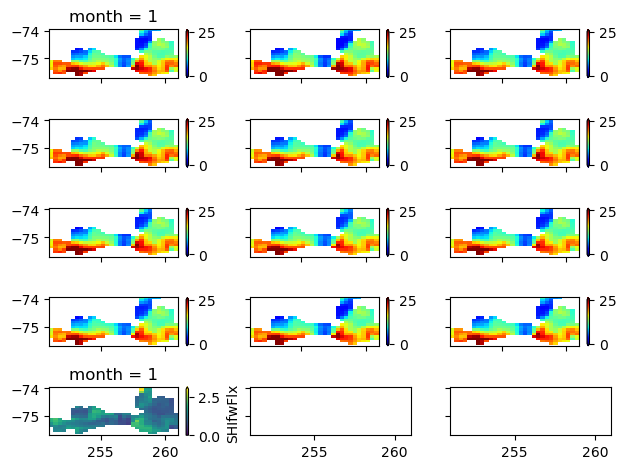

In [117]:
fig, axs = plt.subplots(nrows=5, ncols=3, sharex=True, sharey=True)

axs = axs.flatten()

for i in range(12):

    (c1 * mask * fw_flux_clim[i,:,:]).plot(ax=axs[i], vmin=0, vmax=25, cmap='jet',
                                          cbar_kwargs={"label": ""},
                                          )
    
(c1 * mask * (fw_flux_clim.max(dim='month', skipna=True) - fw_flux_clim.min(dim='month', skipna=True))).plot(
    ax=axs[12],
    vmin=0, vmax=3)
    
for i in range(15):
    axs[i].set_ylim([-75.7, -73.95])
    axs[i].set_ylabel('')
    axs[i].set_xlim([251,261])
    axs[i].set_xlabel('')
    
plt.tight_layout()

## Checking Totten ice sheet

In [29]:
Names[41]

'Totten'

In [2]:
ds_BGOSE_1 = xr.open_dataset("iceshelves_bgose6_v2.nc")
ds_BGOSE_2 = xr.open_dataset("iceshelves_bgose6_extended.nc")

ds1 = xr.open_dataset("BGOSE6/SHIfwFlx_bgoseI000_SO_monthly.nc", use_cftime=True)

Gt_per_yr = -1 * 60**2 * 24 * 365 * 1e-12
m_per_year = -1 * 60**2 * 365 * 24 * 1e-3 

In [3]:
mask_T_lower = (ds_BGOSE_1.ID == 41).rename({'lon':'XC', 'lat':'YC'})
mask_T_upper = (ds_BGOSE_2.shelf_mask == 41)

In [4]:
melt_T_lower_ts = (ds1.SHIfwFlx * mask_T_lower * ds1.rA * Gt_per_yr).sum(dim=['XC', 'YC'])
melt_T_upper_ts = (ds1.SHIfwFlx * mask_T_upper * ds1.rA * Gt_per_yr).sum(dim=['XC', 'YC']) 

melt_T_lower = melt_T_lower_ts[-36:].groupby(melt_T_lower_ts[-36:].time.dt.month).mean()
melt_T_upper = melt_T_upper_ts[-36:].groupby(melt_T_upper_ts[-36:].time.dt.month).mean()

In [39]:
melt_T_upper_ts[-36:]

<xarray.DataArray (time: 36)> Size: 144B
array([104.49037 , 107.22575 , 108.16855 , 108.059906, 106.4081  ,
       103.34056 , 101.72656 , 101.88649 , 103.131744, 105.61281 ,
       107.11822 , 109.44721 , 112.91185 , 115.91176 , 118.44722 ,
       119.40808 , 118.89586 , 117.02519 , 114.67449 , 111.765495,
       110.90065 , 109.71543 , 109.37152 , 110.4118  , 113.251434,
       116.03656 , 118.27521 , 120.03998 , 118.515884, 116.74095 ,
       113.08101 , 111.66807 , 111.07865 , 110.08968 , 109.53824 ,
       111.00191 ], dtype=float32)
Coordinates:
    iter     (time) int64 288B ...
  * time     (time) object 288B 2019-12-30 10:00:00 ... 2022-11-29 00:00:00

[Text(2, 0, 'Feb'),
 Text(4, 0, 'Apr'),
 Text(6, 0, 'Jun'),
 Text(8, 0, 'Aug'),
 Text(10, 0, 'Oct'),
 Text(12, 0, 'Dec')]

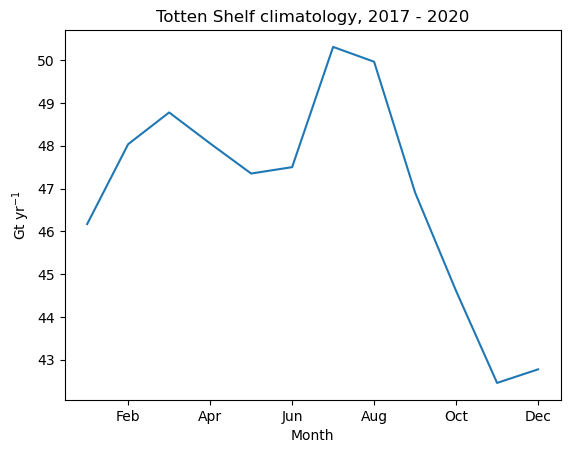

In [6]:
#melt_T_lower.plot()
fig, axs = plt.subplots()

melt_T_upper.plot()
plt.title('Totten Shelf climatology, 2017 - 2020')
plt.ylabel('Gt yr$^{-1}$')
plt.xlabel('Month')
axs.set_xticks(np.arange(2,13,2))
axs.set_xticklabels(['Feb', 'Apr', 'Jun', 'Aug', 'Oct', 'Dec'])

In [ ]:
ds_BGOSE

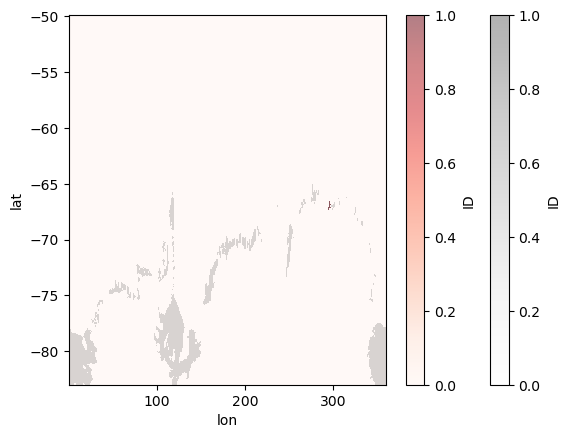

In [52]:
(ds_BGOSE.ID >= 0).plot(cmap='Greys', alpha=0.3)
(ds_BGOSE.ID == 41).plot(cmap='Reds', alpha=0.5) # = xr.open_dataset("iceshelves_bgose_extended.nc")
#plt.xlim([80, 120])

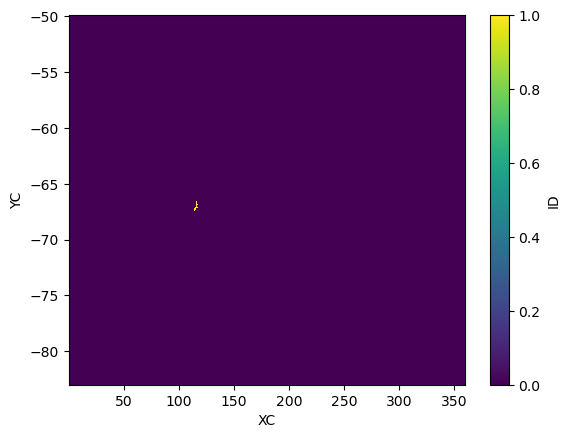

In [24]:
mask_T.plot()